In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as ss

DATASET  LOADING

In [86]:
df2 = pd.read_excel("Telco_customer_churn.xlsx")

In [87]:
df = df2.copy()

DATA PREPROCESSING

In [88]:
df.drop(columns=['CustomerID','Country','State','Count','Zip Code','Lat Long','Churn Score','Churn Label','Churn Reason'],inplace=True)

In [89]:
df.describe()

,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,36.282441,-119.798880,32.371149,64.761692,0.265370,4400.295755
std,2.455723,2.157889,24.559481,30.090047,0.441561,1183.057152
min,32.555828,-124.301372,0.000000,18.250000,0.000000,2003.000000
25%,34.030915,-121.815412,9.000000,35.500000,0.000000,3469.000000
50%,36.391777,-119.730885,29.000000,70.350000,0.000000,4527.000000
75%,38.224869,-118.043237,55.000000,89.850000,1.000000,5380.500000
max,41.962127,-114.192901,72.000000,118.750000,1.000000,6500.000000


In [90]:
df['Churn Value'] = df['Churn Value'].astype('object')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [91]:
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].mean())

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Latitude           7043 non-null   float64
 2   Longitude          7043 non-null   float64
 3   Gender             7043 non-null   object 
 4   Senior Citizen     7043 non-null   object 
 5   Partner            7043 non-null   object 
 6   Dependents         7043 non-null   object 
 7   Tenure Months      7043 non-null   int64  
 8   Phone Service      7043 non-null   object 
 9   Multiple Lines     7043 non-null   object 
 10  Internet Service   7043 non-null   object 
 11  Online Security    7043 non-null   object 
 12  Online Backup      7043 non-null   object 
 13  Device Protection  7043 non-null   object 
 14  Tech Support       7043 non-null   object 
 15  Streaming TV       7043 non-null   object 
 16  Streaming Movies   7043 

In [93]:
df['Year'] = np.round(df['Tenure Months']/12,2)

EXPLORATRY DATA ANALYSIS

Text(0, 0.5, 'Number Of People')

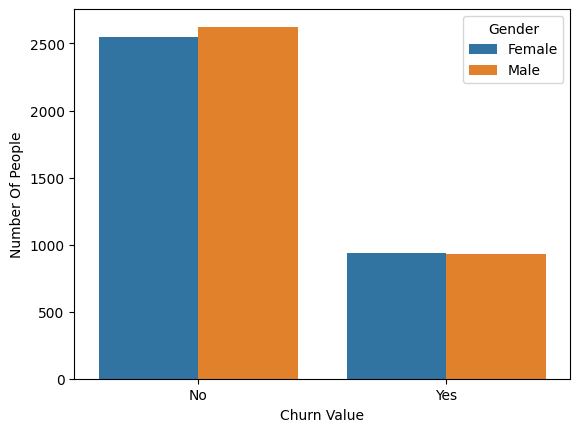

In [10]:
ss.countplot(data=df,x="Churn Value",hue="Gender")
mp.xticks([0,1],['No','Yes'])
mp.ylabel("Number Of People")

Text(589.851399209105, 0.5, 'Number Of People')

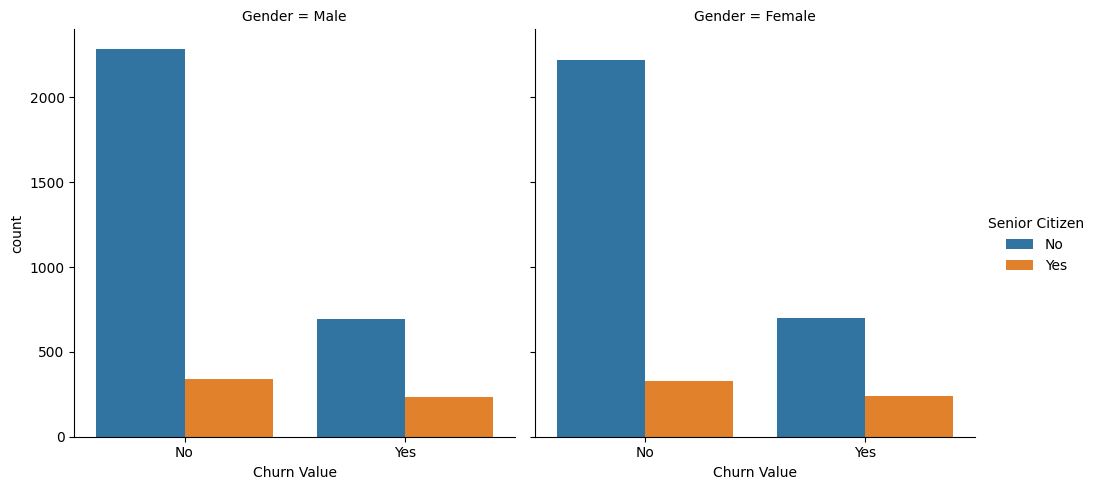

In [11]:
ss.catplot(data=df,x="Churn Value",hue="Senior Citizen",col="Gender",kind="count")
mp.xticks([0,1],['No','Yes'])
mp.ylabel("Number Of People")

Text(570.8165442708333, 0.5, 'Number of People')

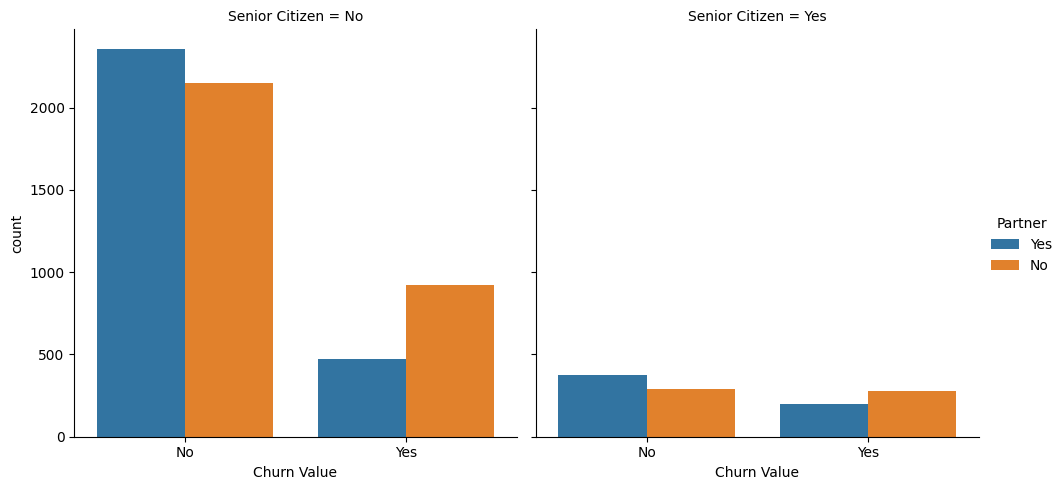

In [12]:
ss.catplot(data=df,x="Churn Value",hue="Partner",kind="count",col="Senior Citizen")
mp.xticks([0,1],['No','Yes'])
mp.ylabel("Number of People")

([<matplotlib.axis.XTick at 0x27bb48d7750>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

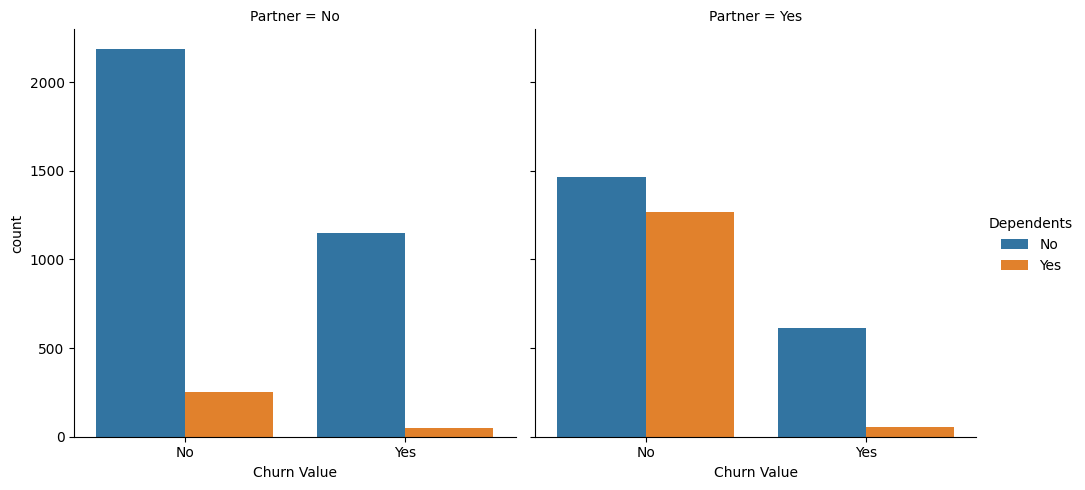

In [13]:
ss.catplot(data=df,x="Churn Value",hue="Dependents",col="Partner",kind="count")
mp.xticks([0,1],['No','Yes'])

Text(0, 0.5, 'Number of People')

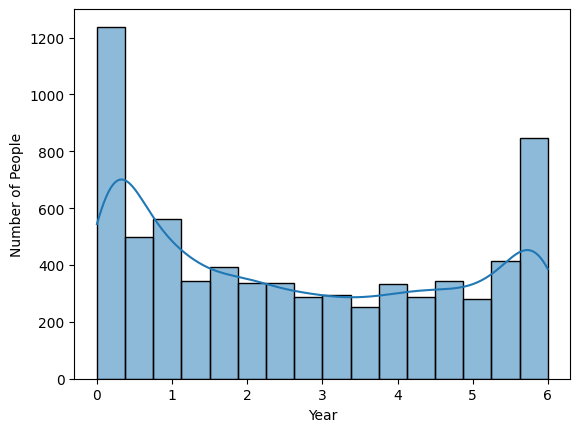

In [14]:
ss.histplot(data=df,x="Year",kde=True)
mp.ylabel("Number of People")

<Axes: xlabel='Churn Value', ylabel='Year'>

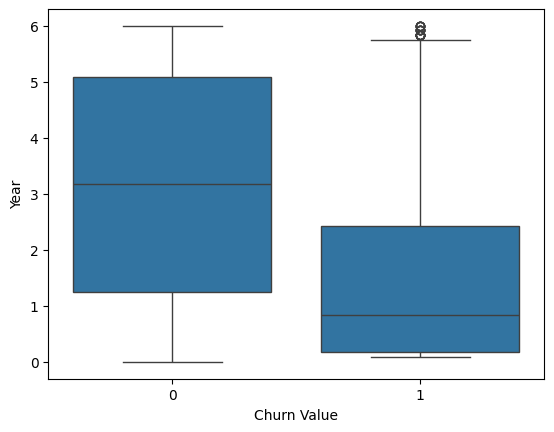

In [15]:
ss.boxplot(data=df,x="Churn Value",y="Year")

Text(591.1389625771606, 0.5, 'Number of People')

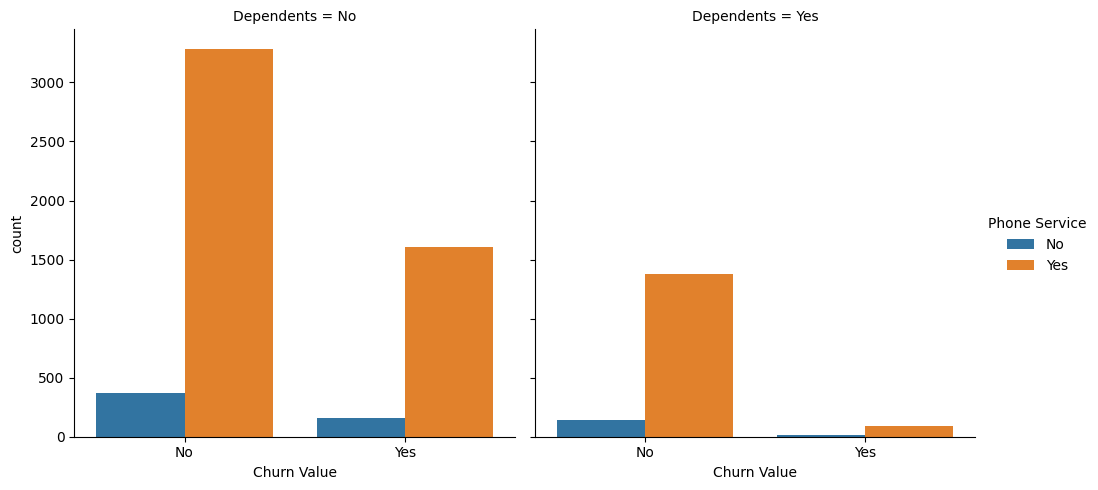

In [16]:
ss.catplot(data=df,x="Churn Value",hue="Phone Service",col="Dependents",kind="count")
mp.xticks([0,1],['No','Yes'])
mp.ylabel("Number of People")

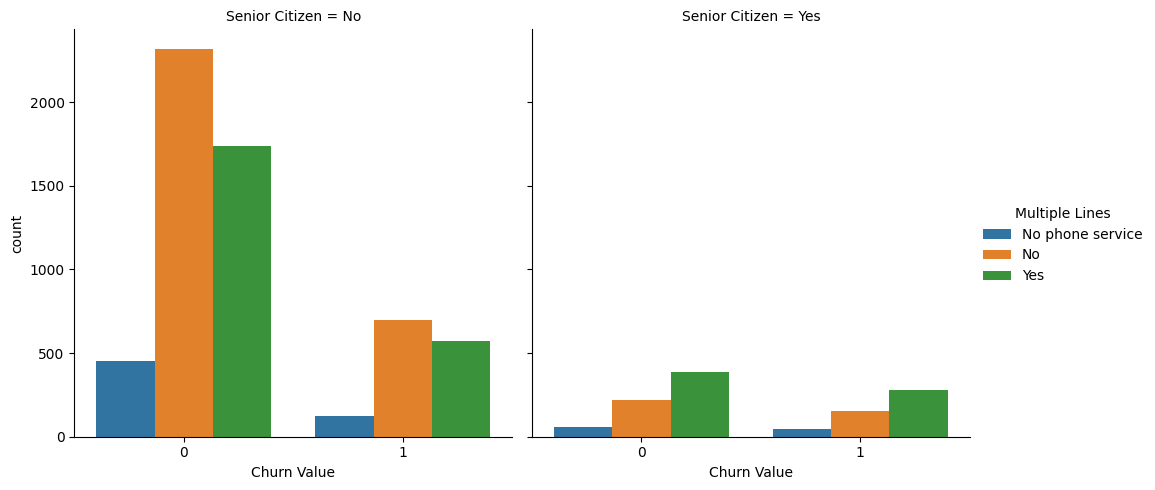

In [17]:
ss.catplot(data=df,x="Churn Value",hue="Multiple Lines",col="Senior Citizen",kind="count")

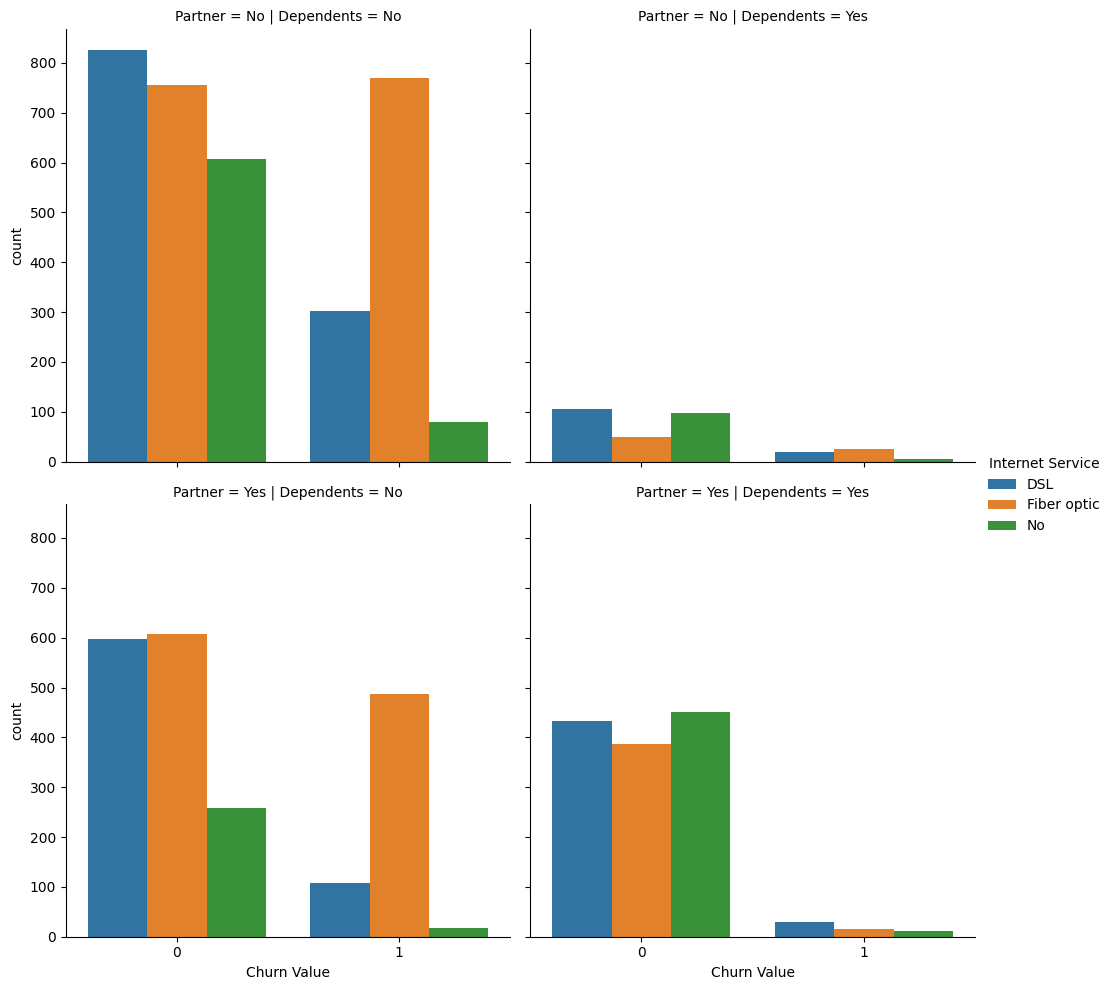

In [18]:
ss.catplot(data=df,x="Churn Value",hue="Internet Service",col="Dependents",row="Partner",kind="count")

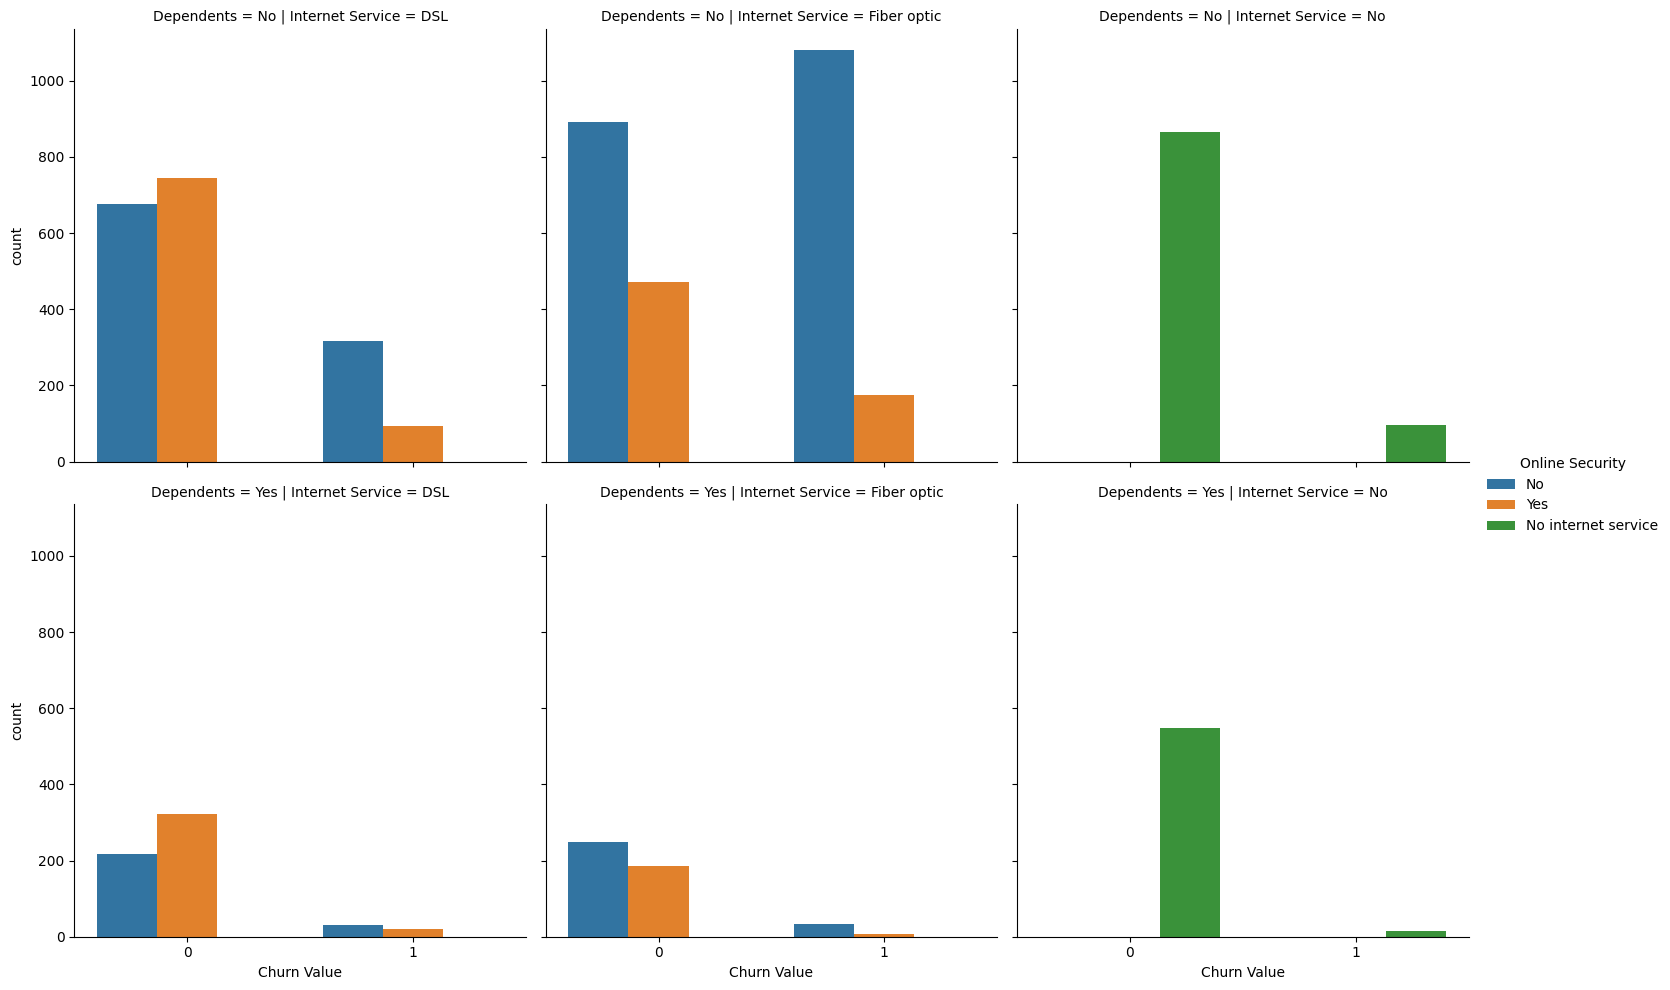

In [19]:
ss.catplot(data=df,x="Churn Value",hue="Online Security",col="Internet Service",row='Dependents',kind="count")

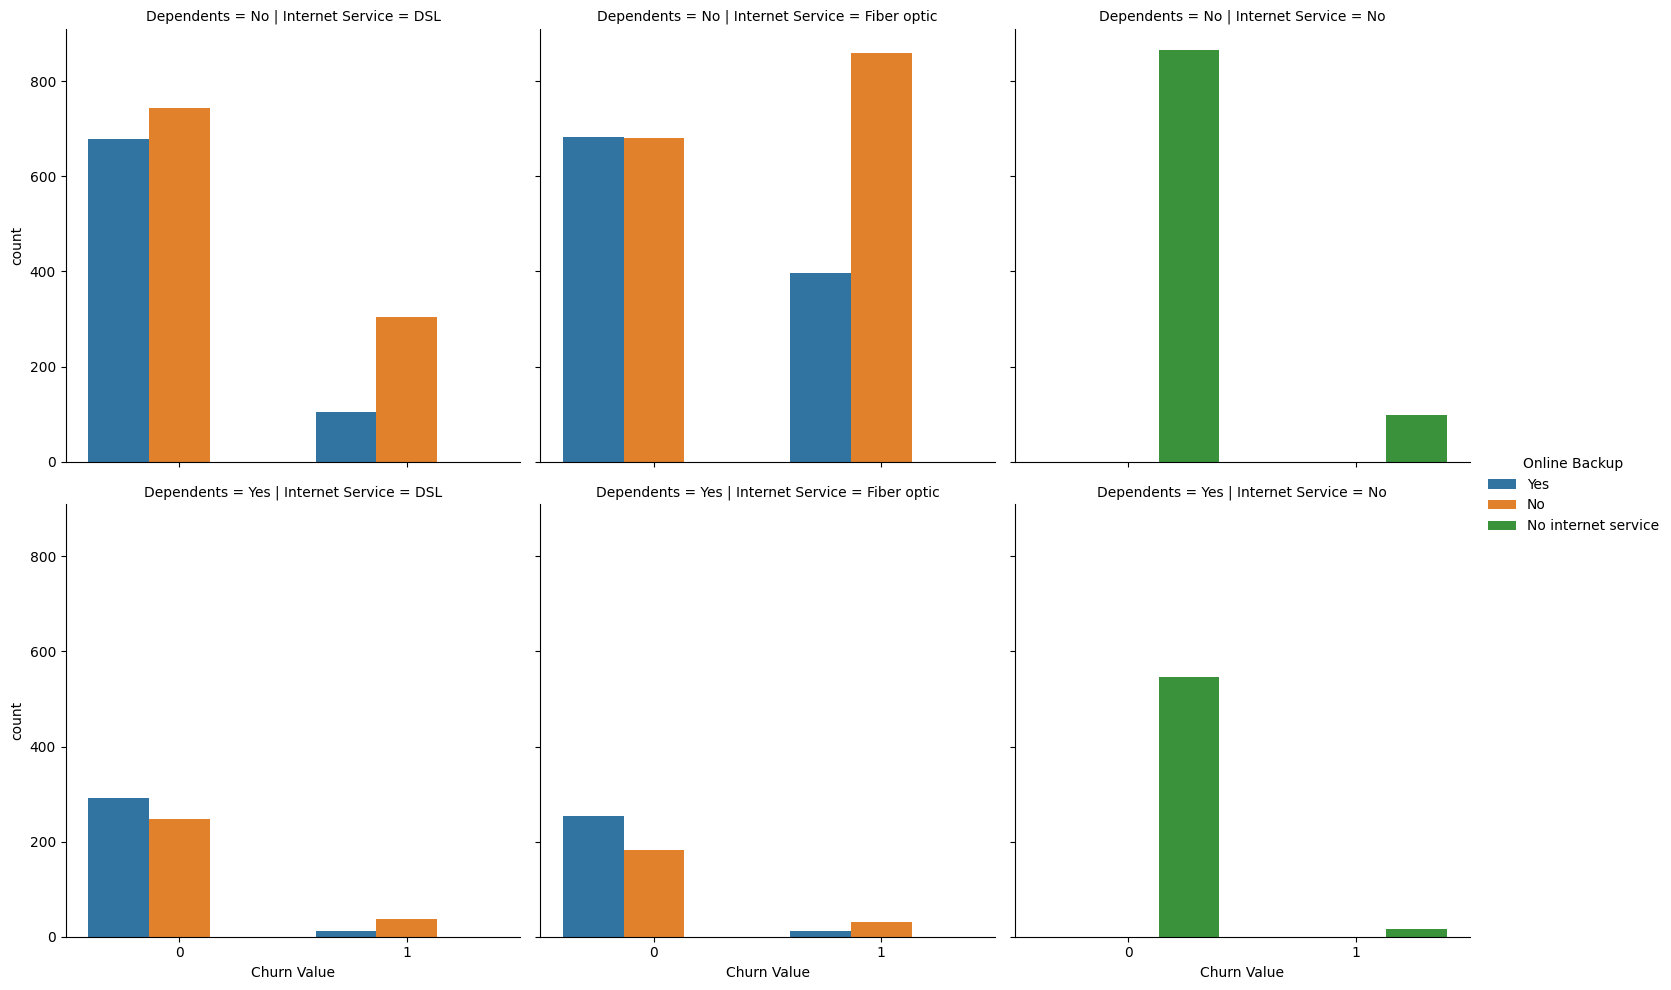

In [20]:
ss.catplot(data=df,x="Churn Value",hue="Online Backup",kind="count",col="Internet Service",row="Dependents")

In [21]:
tech = pd.crosstab(df['Tech Support'],df['Churn Value'],normalize='index')*100

In [22]:
tv = pd.crosstab(df['Streaming TV'],df['Churn Value'],normalize='index')*100

In [23]:
tech

Churn Value,0,1
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [24]:
tv

Churn Value,0,1
Streaming TV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


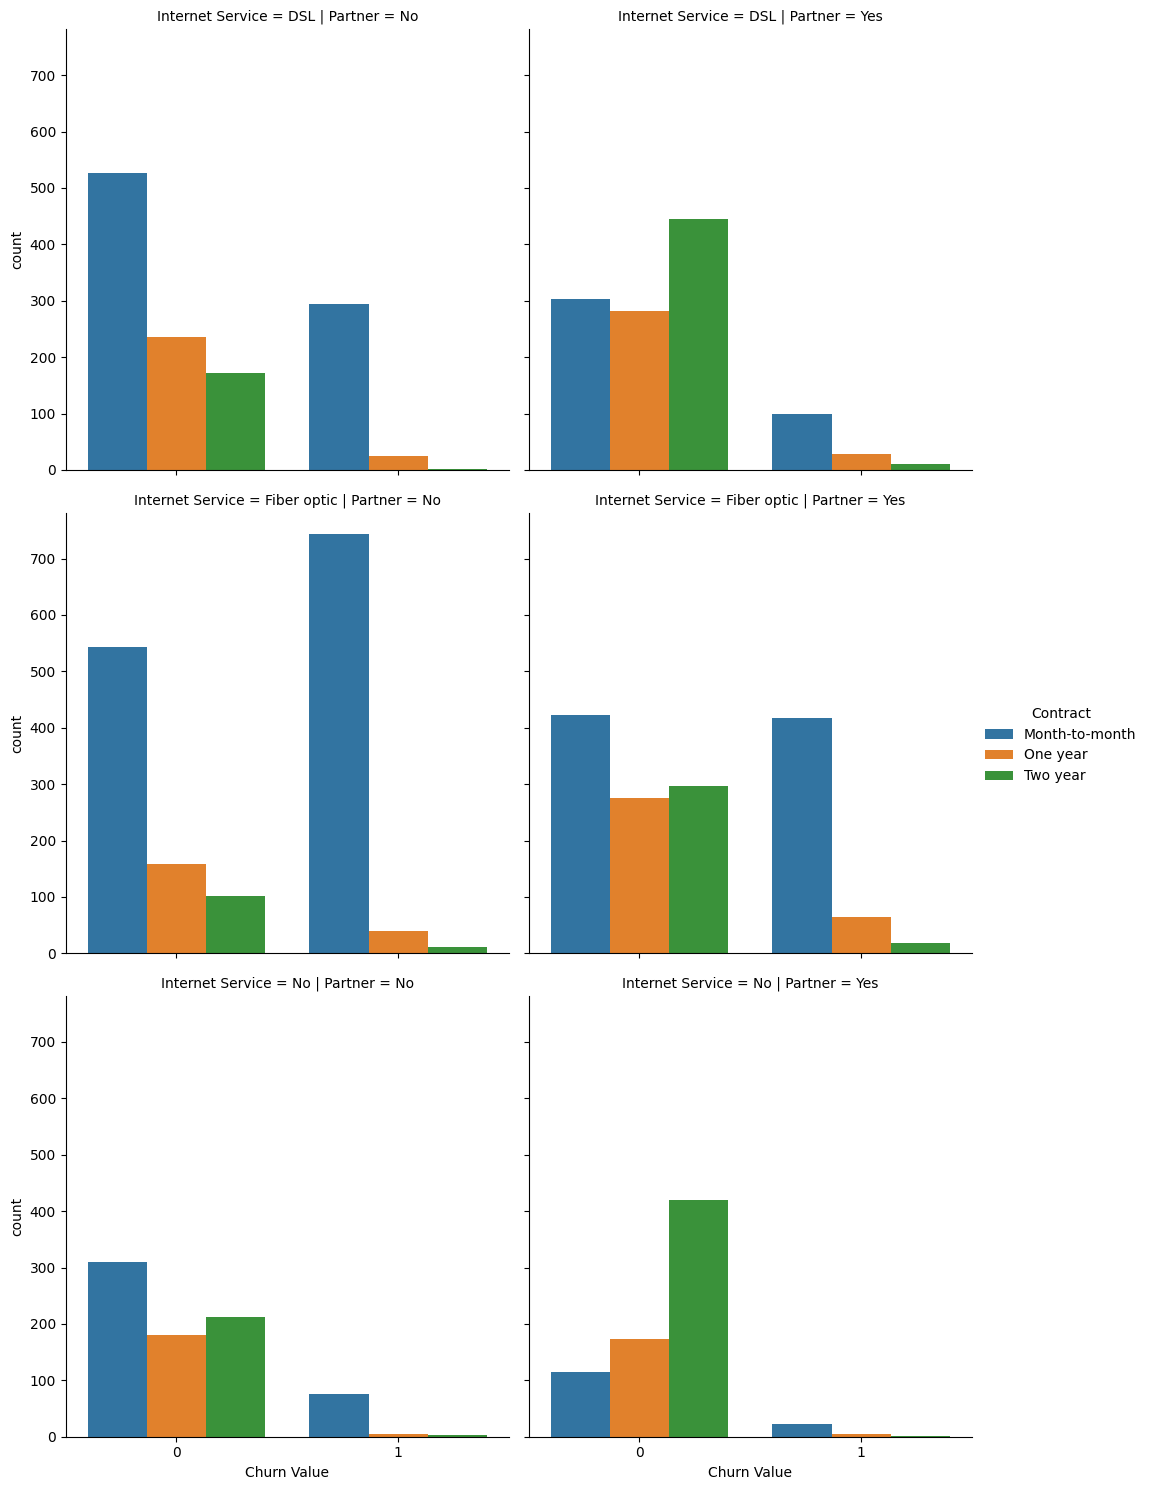

In [25]:
ss.catplot(data=df,x="Churn Value",hue="Contract",kind="count",col="Partner",row="Internet Service")

In [26]:
contract = pd.crosstab(index=[df['Contract'],df['Internet Service']],columns=df['Churn Value'],normalize='index')*100

In [27]:
contract

Churn Value                              0          1
Contract       Internet Service                      
Month-to-month DSL               67.784137  32.215863
               Fiber optic       45.394737  54.605263
               No                81.106870  18.893130
One year       DSL               90.701754   9.298246
               Fiber optic       80.705009  19.294991
               No                97.527473   2.472527
Two year       DSL               98.089172   1.910828
               Fiber optic       92.773893   7.226107
               No                99.216301   0.783699

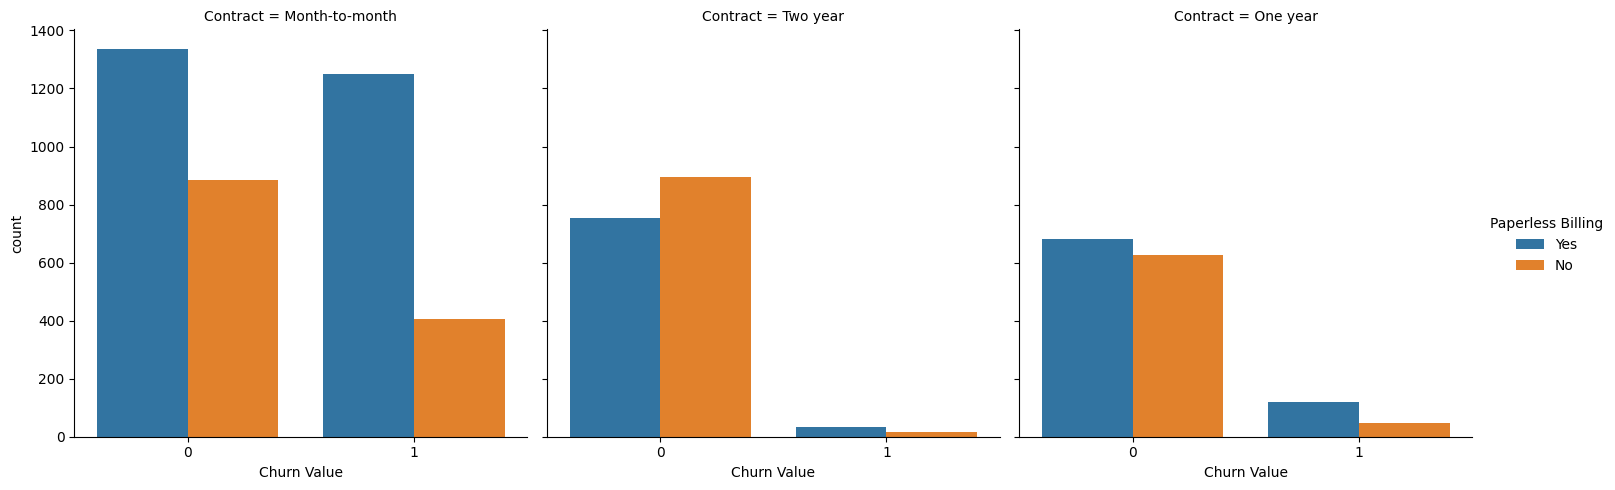

In [28]:
ss.catplot(data=df,x="Churn Value",hue="Paperless Billing",col="Contract",kind="count")

In [29]:
bill = pd.crosstab(index=[df['Paperless Billing'],df['Contract']],columns=df['Churn Value'],normalize='index')*100

In [30]:
bill

Churn Value                               0          1
Paperless Billing Contract                            
No                Month-to-month  68.502715  31.497285
                  One year        92.867756   7.132244
                  Two year        98.351648   1.648352
Yes               Month-to-month  51.701469  48.298531
                  One year        85.250000  14.750000
                  Two year        95.796178   4.203822

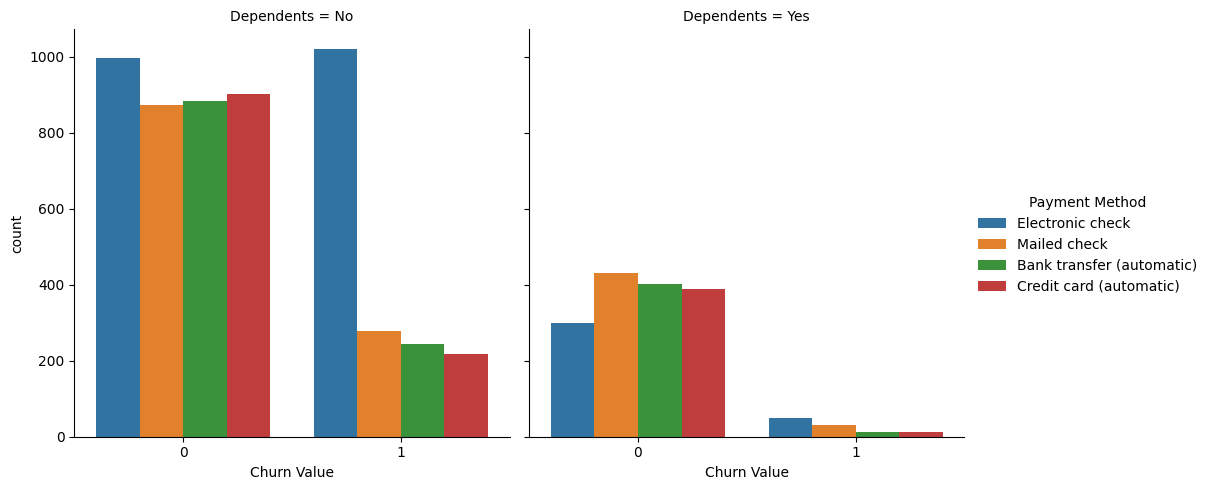

In [31]:
ss.catplot(data=df,x="Churn Value",hue="Payment Method",kind="count",col="Dependents")

<Axes: xlabel='Monthly Charges', ylabel='Count'>

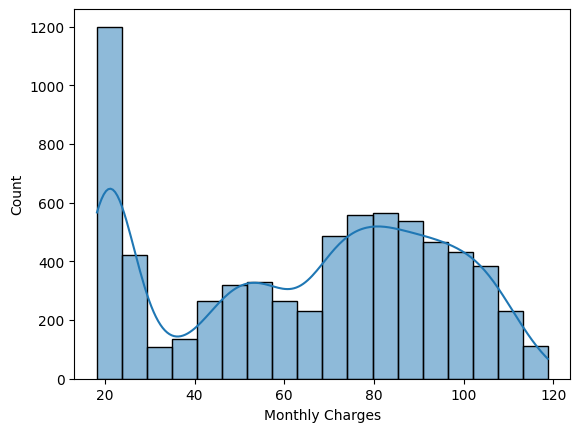

In [32]:
ss.histplot(data=df,x="Monthly Charges",kde=True)

<Axes: xlabel='Churn Value', ylabel='Monthly Charges'>

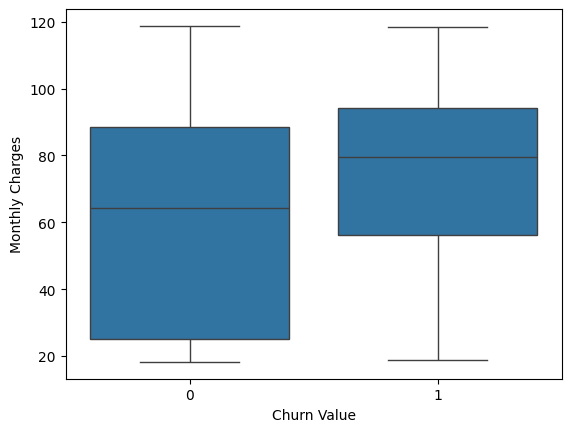

In [33]:
ss.boxplot(data=df,x="Churn Value",y="Monthly Charges")

<Axes: xlabel='Total Charges', ylabel='Count'>

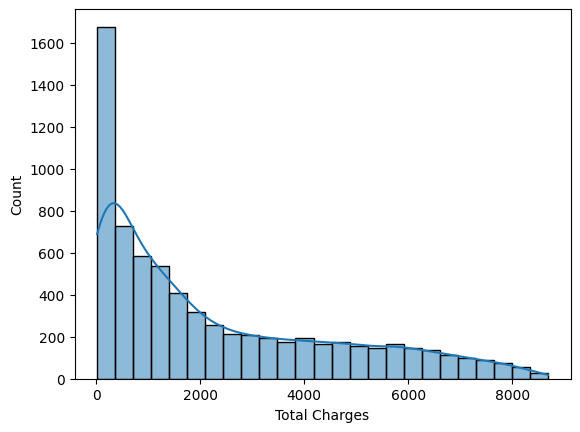

In [34]:
ss.histplot(data=df,x="Total Charges",kde=True)

<Axes: xlabel='Churn Value', ylabel='Total Charges'>

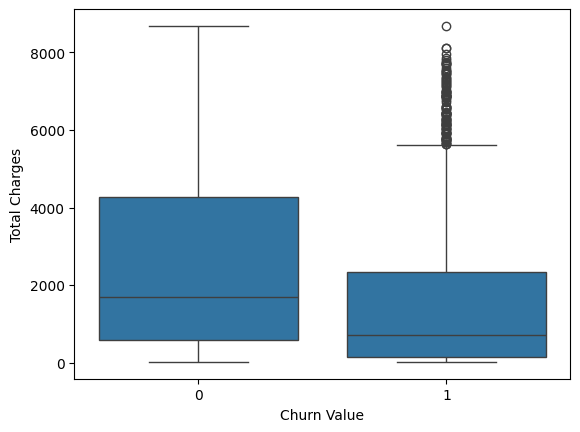

In [35]:
ss.boxplot(data=df,x="Churn Value",y="Total Charges")

In [36]:
Q1 = df['Total Charges'].quantile(0.25)
Q3 = df['Total Charges'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

In [37]:
df['Total Charges'] = np.where(
    df['Total Charges'] > upper_limit,
    upper_limit,
    df['Total Charges']
)

In [38]:
import plotly.express as px

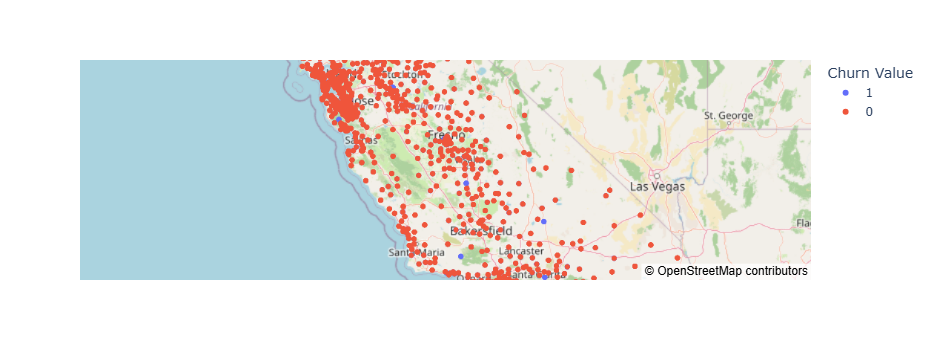

In [39]:
fig = px.scatter_map(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Churn Value",
    hover_name="City",
    zoom=5,
    map_style="open-street-map"
)

fig.show()

<Axes: xlabel='CLTV', ylabel='Count'>

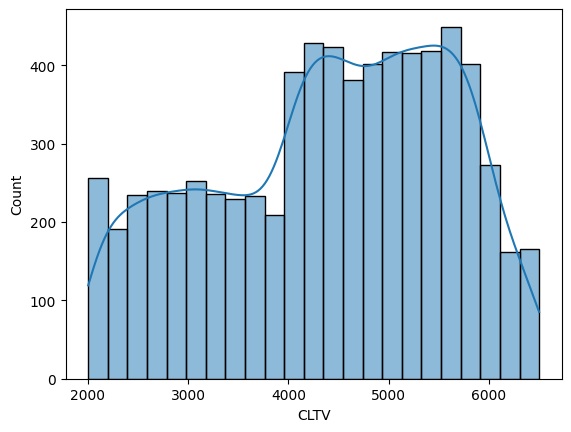

In [40]:
ss.histplot(data=df,x="CLTV",kde=True)

MODEL BUILDING

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
df['Churn Value'] = df['Churn Value'].astype(int)

In [43]:
df.drop(columns=['Year'],inplace=True)

In [44]:
df.drop(columns=['Multiple Lines','Senior Citizen','Gender','Phone Service','Device Protection','Total Charges','Monthly Charges','Latitude','Longitude','CLTV','Online Backup','Partner'],inplace=True)

In [45]:
x = df.drop(columns=['Churn Value'])
y = df['Churn Value']

In [205]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [206]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder , PowerTransformer 
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier , RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score , roc_curve

In [207]:
object_cols = x.select_dtypes(include='object').columns

In [208]:
object_cols

Index(['City', 'Dependents', 'Internet Service', 'Online Security',
       'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract',
       'Paperless Billing', 'Payment Method'],
      dtype='object')

In [209]:
num_cols = x.select_dtypes(include='number').columns

In [210]:
num_cols

Index(['Tenure Months'], dtype='object')

In [269]:
op1 = ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False),object_cols),
    ('log',StandardScaler(),num_cols)
],remainder='passthrough')

In [270]:
op4 = GradientBoostingClassifier(n_estimators=302,learning_rate=0.35,max_depth=10)

In [271]:
op5= XGBClassifier(n_estimators=50,learning_rate=0.1,max_depth=3,random_state=42)

In [272]:
op6 = SMOTE()

In [273]:
pipe = Pipeline([
    ('preprocessor1', op1),
    ('Smote',op6),
    ('model', op5)])

In [274]:
pipe.fit(x_train,y_train)

,steps,"[('preprocessor1', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('log', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatt

In [275]:
param_grid = {
    'model__n_estimators': [50,100,150],
    'model__max_depth': [3, 5 , 7 , 4],
    'model__learning_rate': [0.01, 0.1 , 0.01 , 0.03]
}

In [276]:
from sklearn.model_selection import RandomizedSearchCV

In [277]:
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42)

In [278]:
random_search.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [279]:
random_search.best_params_

{'model__n_estimators': 50, 'model__max_depth': 3, 'model__learning_rate': 0.1}

In [280]:
random_search.best_score_

np.float64(0.8573325143946274)

In [281]:
predict = random_search.predict(x_test)

MODEL EVALUATION METRICS

In [282]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report
from sklearn.model_selection import GridSearchCV,cross_val_score

In [294]:
y_prob = pipe.predict_proba(x_test)[:,1]

In [295]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    
    y_pred = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.3 | Precision: 0.481 | Recall: 0.925
Threshold: 0.4 | Precision: 0.525 | Recall: 0.880
Threshold: 0.5 | Precision: 0.563 | Recall: 0.785
Threshold: 0.6 | Precision: 0.622 | Recall: 0.688
Threshold: 0.7 | Precision: 0.686 | Recall: 0.580


In [296]:
print(classification_report(y_test,predict,target_names=['Not Churn', 'Churn']))

              precision    recall  f1-score   support

   Not Churn       0.91      0.75      0.82      1009
       Churn       0.57      0.81      0.67       400

    accuracy                           0.77      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.77      0.78      1409



In [297]:
from sklearn.metrics import ConfusionMatrixDisplay

Text(0.5, 1.0, 'Confusion Matrix')

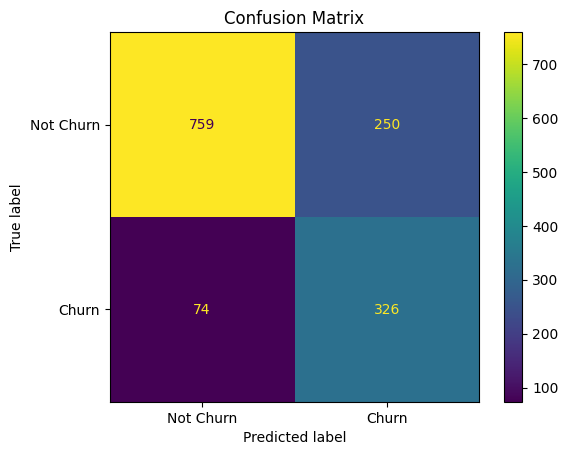

In [298]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predict,
    display_labels=['Not Churn', 'Churn']
)
mp.title("Confusion Matrix")

In [288]:
fpr,tpr,thresold = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)

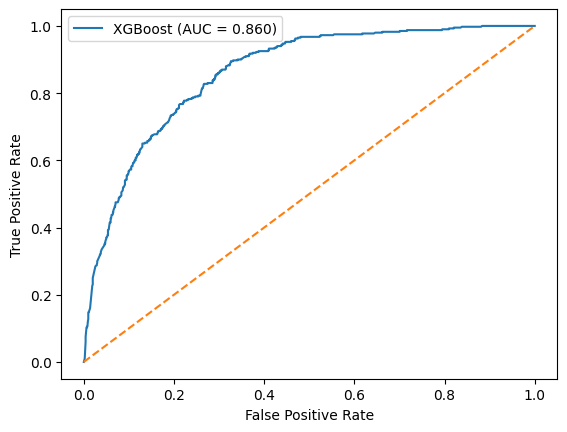

In [289]:
mp.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})')
mp.plot([0, 1], [0, 1], linestyle='--')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.legend()

KEY INSIGHTS

In [302]:
xgb = pipe.named_steps['model']

In [303]:
feature_names = pipe.named_steps['preprocessor1'].get_feature_names_out()

In [304]:
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)

In [306]:
feature_names = pipe.named_steps['preprocessor1'].get_feature_names_out()
importance = pipe.named_steps['model'].feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})
df_imp["feature"] = df_imp["feature"].str.replace(r"^[^_]+__", "", regex=True)
df_imp["original_feature"] = df_imp["feature"].str.split("_").str[0]

result = (
    df_imp.groupby("original_feature")["importance"]
          .sum()
          .sort_values(ascending=False)
)

print(result)

original_feature
Contract             0.330477
City                 0.151536
Online Security      0.100375
Internet Service     0.082730
Payment Method       0.082077
Tech Support         0.063365
Dependents           0.052629
Streaming Movies     0.046156
Streaming TV         0.035159
Paperless Billing    0.028507
Tenure Months        0.026987
Name: importance, dtype: float32
